# Data Exploration (B-1)

This notebook covers Task B-1: Input Data Description and Exploration. It explores the COCO val2017 dataset, which is the primary evaluation dataset for the open-vocabulary video search project. The same encoders that retrieve from COCO images also retrieve from video frames, so COCO serves as a controlled benchmark for model selection.

## 1. Setup and Downloads

In [1]:
!pip install -q pycocotools matplotlib pandas seaborn


In [2]:
import os
import json
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("./coco_data")
DATA_DIR.mkdir(exist_ok=True)
ANN_DIR = DATA_DIR / "annotations"

ANN_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
ANN_ZIP = DATA_DIR / "annotations_trainval2017.zip"

if not (ANN_DIR / "instances_val2017.json").exists():
    if not ANN_ZIP.exists():
        print("Downloading COCO annotations...")
        urllib.request.urlretrieve(ANN_URL, ANN_ZIP)
    print("Extracting annotations...")
    with zipfile.ZipFile(ANN_ZIP, "r") as z:
        z.extractall(DATA_DIR)

ANN_FILE = ANN_DIR / "instances_val2017.json"
print(f"Annotations file: {ANN_FILE}")
print(f"Size: {ANN_FILE.stat().st_size / 1e6:.1f} MB")


Extracting annotations...
Annotations file: coco_data/annotations/instances_val2017.json
Size: 20.0 MB


## 2. Dataset Overview

In [3]:
from pycocotools.coco import COCO
coco = COCO(str(ANN_FILE))

img_ids = coco.getImgIds()
ann_ids = coco.getAnnIds()
cat_ids = coco.getCatIds()

print(f"Number of images: {len(img_ids)}")
print(f"Number of annotations: {len(ann_ids)}")
print(f"Number of categories: {len(cat_ids)}")

# Average annotations per image
print(f"Avg annotations per image: {len(ann_ids) / len(img_ids):.1f}")


loading annotations into memory...
Done (t=2.08s)
creating index...
index created!
Number of images: 5000
Number of annotations: 36781
Number of categories: 80
Avg annotations per image: 7.4


In [4]:
# Sample image record
sample_id = img_ids[0]
sample_img = coco.loadImgs(sample_id)[0]
print("Example image record:")
for k, v in sample_img.items():
    print(f"  {k}: {v}")

# Sample annotation
sample_ann = coco.loadAnns(coco.getAnnIds(imgIds=sample_id))[0]
print("\nExample annotation record:")
for k, v in sample_ann.items():
    if k == "segmentation":
        print(f"  {k}: <polygon with {len(v[0]) if isinstance(v, list) and v else 0} points>")
    else:
        print(f"  {k}: {v}")


Example image record:
  license: 4
  file_name: 000000397133.jpg
  coco_url: http://images.cocodataset.org/val2017/000000397133.jpg
  height: 427
  width: 640
  date_captured: 2013-11-14 17:02:52
  flickr_url: http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg
  id: 397133

Example annotation record:
  segmentation: <polygon with 48 points>
  area: 1481.3806499999994
  iscrowd: 0
  image_id: 397133
  bbox: [217.62, 240.54, 38.99, 57.75]
  category_id: 44
  id: 82445


## 3. Category Distribution

COCO has 80 object categories. Their distribution is heavily skewed: "person" alone accounts for a large fraction of all annotations, while categories like "hair drier" and "toaster" appear far less often. This skew has implications for fairness analysis.

In [5]:
cats = coco.loadCats(cat_ids)
cat_counts = []
for c in cats:
    n = len(coco.getAnnIds(catIds=[c["id"]]))
    cat_counts.append({"category": c["name"], "supercategory": c["supercategory"], "count": n})

cat_df = pd.DataFrame(cat_counts).sort_values("count", ascending=False)
print(f"Most common 10 categories:")
print(cat_df.head(10).to_string(index=False))
print(f"\nLeast common 10 categories:")
print(cat_df.tail(10).to_string(index=False))


Most common 10 categories:
     category supercategory  count
       person        person  11004
          car       vehicle   1932
        chair     furniture   1791
         book        indoor   1161
       bottle       kitchen   1025
          cup       kitchen    899
 dining table     furniture    697
traffic light       outdoor    637
         bowl       kitchen    626
      handbag     accessory    540

Least common 10 categories:
     category supercategory  count
 fire hydrant       outdoor    101
    stop sign       outdoor     75
         bear        animal     71
    snowboard        sports     69
parking meter       outdoor     60
   toothbrush        indoor     57
    microwave     appliance     55
     scissors        indoor     36
   hair drier        indoor     11
      toaster     appliance      9


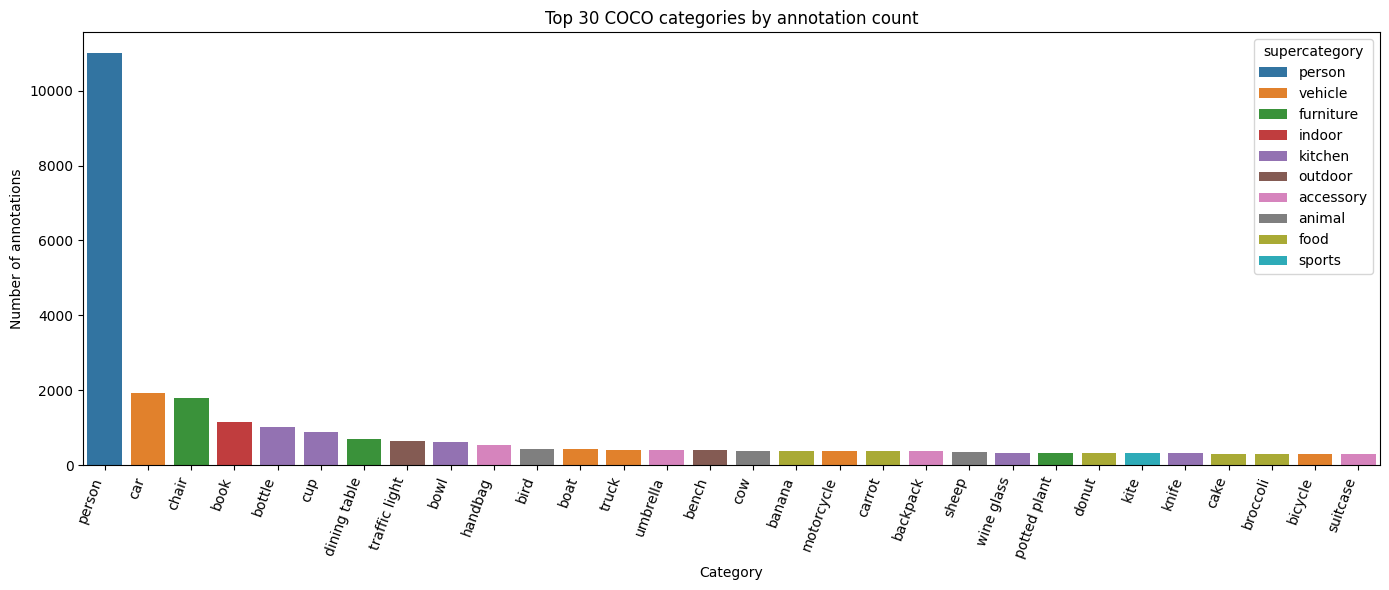

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
top_n = 30
sns.barplot(data=cat_df.head(top_n), x="category", y="count", hue="supercategory", dodge=False, ax=ax)
ax.set_title(f"Top {top_n} COCO categories by annotation count")
ax.set_xlabel("Category")
ax.set_ylabel("Number of annotations")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()


## 4. Object Size Distribution

Object size matters for the retrieval task. Whole-image encoders tend to lose signal for small objects because the small object is averaged into the much larger background. This motivates the SAM2 + SigLIP2 region-level approach. The size distribution below shows that a substantial fraction of COCO objects are small.

In [7]:
# Compute object sizes (as fraction of image area)
sizes = []
for ann in coco.loadAnns(ann_ids):
    img = coco.loadImgs(ann["image_id"])[0]
    img_area = img["width"] * img["height"]
    obj_area = ann["area"]
    if img_area > 0:
        sizes.append(obj_area / img_area * 100)  # percent

sizes = np.array(sizes)
print(f"Object size statistics (% of image area):")
print(f"  Median: {np.median(sizes):.2f}%")
print(f"  Mean: {sizes.mean():.2f}%")
print(f"  Small objects (< 5% of image): {(sizes < 5).sum()} ({(sizes < 5).mean()*100:.1f}%)")
print(f"  Large objects (> 30% of image): {(sizes > 30).sum()} ({(sizes > 30).mean()*100:.1f}%)")


Object size statistics (% of image area):
  Median: 0.63%
  Mean: 4.35%
  Small objects (< 5% of image): 29653 (80.6%)
  Large objects (> 30% of image): 1168 (3.2%)


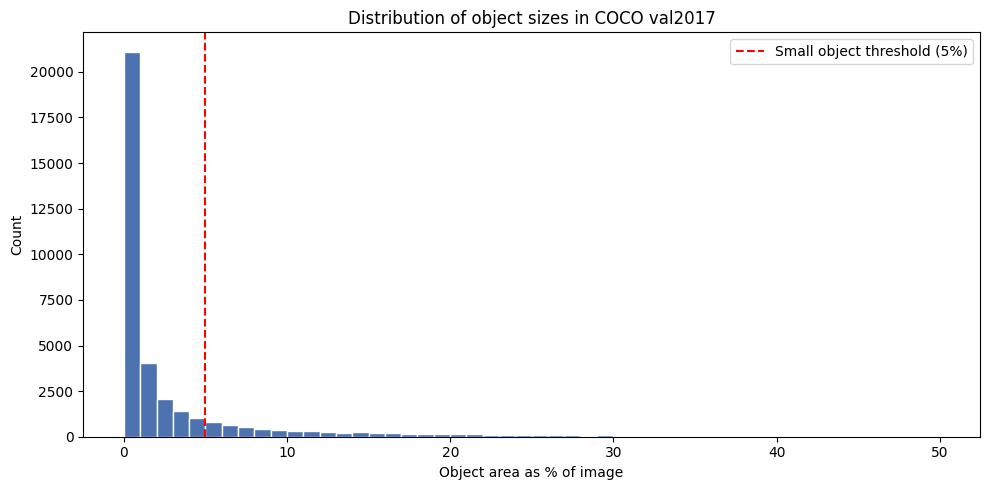

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sizes[sizes < 50], bins=50, color="#4c72b0", edgecolor="white")
ax.axvline(5, color="red", linestyle="--", label="Small object threshold (5%)")
ax.set_title("Distribution of object sizes in COCO val2017")
ax.set_xlabel("Object area as % of image")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Annotations Per Image

In [9]:
anns_per_img = []
for iid in img_ids:
    anns_per_img.append(len(coco.getAnnIds(imgIds=iid)))

anns_per_img = np.array(anns_per_img)
print(f"Annotations per image:")
print(f"  Mean: {anns_per_img.mean():.1f}")
print(f"  Median: {np.median(anns_per_img):.0f}")
print(f"  Max: {anns_per_img.max()}")
print(f"  Images with 0 annotations: {(anns_per_img == 0).sum()}")
print(f"  Images with 10+ annotations: {(anns_per_img >= 10).sum()}")


Annotations per image:
  Mean: 7.4
  Median: 4
  Max: 63
  Images with 0 annotations: 48
  Images with 10+ annotations: 1332


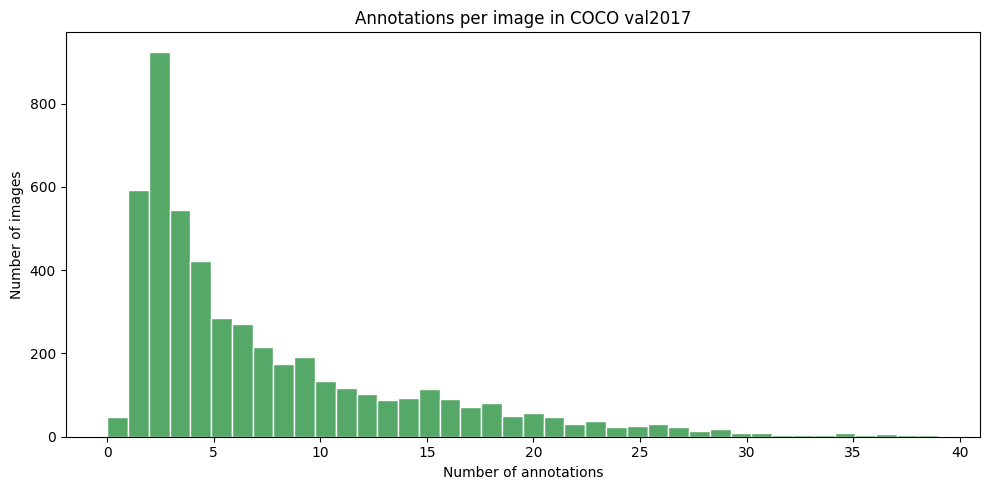

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(anns_per_img[anns_per_img < 40], bins=40, color="#55a868", edgecolor="white")
ax.set_title("Annotations per image in COCO val2017")
ax.set_xlabel("Number of annotations")
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.show()


## 6. Sensitive Features and Fairness Considerations

Several sensitive attributes appear in COCO:

- **People ("person" category).** People appear in many images and are the most common single annotation. COCO's source images come from Flickr and have documented demographic representation imbalances (geographic, age, gender skews).
- **Object category imbalance.** As shown above, common classes like person and car have far more examples than rare classes like hair drier. This affects per-category retrieval performance.

For our project, sensitive features are handled in two ways:

1. **Object retrieval:** we report per-category Recall@5 (notebook 03, Section 12) so categories that systematically underperform are visible.
2. **Face matching:** the production system uses watchlist-based matching, where biometric embeddings are generated only for individuals the user has explicitly authorized through reference photos. The system does not perform persistent biometric clustering of bystanders. This design decision (documented in the SRS) limits exposure to demographic bias in face matching.


In [11]:
# Confirm "person" is the most common category
person_id = coco.getCatIds(catNms=["person"])[0]
person_count = len(coco.getAnnIds(catIds=[person_id]))
print(f"\"person\" annotations: {person_count}")
print(f"Total annotations: {len(ann_ids)}")
print(f"\"person\" share: {person_count / len(ann_ids) * 100:.1f}%")


"person" annotations: 11004
Total annotations: 36781
"person" share: 29.9%


## 7. Query Set Used for Evaluation

For model selection (notebook 03), we use a curated set of 19 text queries grouped into 3 categories. The original design included 5 categories with color-attributed queries (e.g., 'a red car'), but those were excluded from the eval because COCO annotations only encode object categories, not visual attributes (see notebook 03 methodology note). The categories let us analyze where each pipeline succeeds and fails.


In [12]:
query_categories = {
    "1_simple": "Simple objects (e.g., 'a cat', 'a car')",
    "3_relational": "Relational queries (e.g., 'person riding a bicycle')",
    "4_small_background": "Small or background objects (e.g., 'a small bottle on a table')",
}

# Original design also included these two categories, excluded from eval because
# COCO labels do not encode visual attributes:
excluded_categories = {
    "2_attributed": "Attributed objects (e.g., 'a red car', 'a yellow taxi')",
    "5_attributed_small": "Attributed small objects (e.g., 'a red backpack on the floor')",
}

print("Query categories used in evaluation:\n")
for code_name, desc in query_categories.items():
    print(f"  {code_name}: {desc}")
print("\nExcluded (attribute queries cannot be verified against COCO category-only labels):")
for code_name, desc in excluded_categories.items():
    print(f"  {code_name}: {desc}")


Query categories used in evaluation:

  1_simple: Simple objects (e.g., 'a cat', 'a car')
  3_relational: Relational queries (e.g., 'person riding a bicycle')
  4_small_background: Small or background objects (e.g., 'a small bottle on a table')

Excluded (attribute queries cannot be verified against COCO category-only labels):
  2_attributed: Attributed objects (e.g., 'a red car', 'a yellow taxi')
  5_attributed_small: Attributed small objects (e.g., 'a red backpack on the floor')


## 8. Large-Scale Data Strategy

COCO val2017 fits in memory and requires no streaming or distributed training for evaluation. For the production video system, the strategy combines:

- **Async ingestion** through Celery and Redis. Each video is processed in the background by a GPU worker.
- **Parallel processing across videos.** Multiple GPU workers process different videos concurrently.
- **Batched encoding within a video.** SigLIP2 region encoding batches up to 32 crops per GPU call.
- **Frame-level deduplication before SAM2** to skip near-duplicate frames in static surveillance scenes, which dramatically reduces compute.

This is documented in detail in the SRS and the report's Part A.

## Summary

COCO val2017 contains 5,000 images annotated with bounding boxes across 80 categories. Key characteristics relevant to this project:

- Heavy category imbalance ("person" dominates).
- Substantial fraction of small objects (< 5% of image area), motivating region-level retrieval.
- Average ~7 annotations per image, with a wide spread.
- Person-related content is prevalent, making demographic bias considerations relevant.

Subsequent notebooks build on this dataset: 02_pipeline_setup (encodes images and indexes SAM2 regions to a Drive cache), 03_trained_scoring_head (trains 4 model variants and compares 4 pipelines, B-2/B-3/B-4 deliverable), and 04_explainability_trained_model (per-prediction reasoning with SHAP, B-5/B-6 deliverable).
